In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import tensorflow.keras.layers as KL
from PIL import Image
%matplotlib inline

In [ ]:

# from google.colab import files
# uploaded = files.upload()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# train=['nonfall_skel_1_RGB.mp4','nonfall_skel_2_RGB.mp4','fall_skel_1_RGB.mp4','fall_skel_2_RGB.mp4']
# test=['nonfall_skel_3_RGB.mp4','fall_skel_3_RGB.mp4']

In [ ]:

import cv2
location_m = '/content/drive/My Drive/Colab Notebooks/'
location_s = '/content/drive/My Drive/'
def data_collector(name,i,j):
  images = []
  target = []
  count = 0
  co = 0
  for ele in range(i,j+1):
    cap = cv2.VideoCapture(location_m+'Videos/'+name+'/'+'skel_'+str(ele)+'_RGB.avi')
    frames = []
    temp_target = []
    while cap.isOpened():
        ret, image = cap.read()
        if not ret:
          break
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        # cv2_imshow(image) # Note cv2_imshow, not cv2.imshow
        frames.append(gray)
        count = count + 1
        if(name == 'Fall'):
          temp_target.append(1)
        else:
          temp_target.append(0)
    frames = np.array(frames)
    temp_target = np.array(temp_target)
    if(len(frames)>125):
        frames = frames[-125:]
        temp_target = temp_target[-125:]

    images.append(frames)
    target.append(temp_target)
    co += 1
    cv2.waitKey(1) & 0xff
    cv2.destroyAllWindows()
    cap.release()
  images = np.array(images)

  target = np.array(target)
  return images , target

In [ ]:
images_fall, target_fall = data_collector('Fall',1,30)
images_not_fall , target_not_fall = data_collector('NotFall',1,13)

In [ ]:
# np.squeeze(images_fall,axis = (2,))
len(target_fall)

30

In [ ]:
images_fall.shape

(30,)

In [ ]:
# print(count)

In [ ]:
images_fall_f = []
for l in images_fall:
    for f in l:
        images_fall_f.append(f)

images_fall_f = np.array(images_fall_f)
print(images_fall_f.shape)
target_fall_f = []
for l in target_fall:
    for f in l:
        target_fall_f.append(f)

target_fall_f = np.array(target_fall_f)
print(target_fall_f.shape)

images_not_fall_f = []
for l in images_not_fall:
    for f in l:
        images_not_fall_f.append(f)

images_not_fall_f = np.array(images_not_fall_f)
print(images_not_fall_f.shape)
target_not_fall_f = []
for l in target_not_fall:
    for f in l:
        target_not_fall_f.append(f)

target_not_fall_f = np.array(target_not_fall_f)
print(target_not_fall_f.shape)

(2618, 288, 384)
(2618,)
(1625, 288, 384)
(1625,)


In [ ]:
images_fall = images_fall_f
target_fall = target_fall_f
images_not_fall = images_not_fall_f
target_not_fall = target_not_fall_f

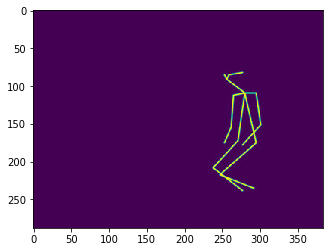

In [ ]:

from matplotlib import pyplot as plt
plt.imshow(images_fall[134], interpolation='nearest')
plt.show()

In [ ]:
x = images_fall.shape[0] - int(images_fall.shape[0]*0.3)
x_trainf = images_fall[:x]
x_testf = images_fall[x:]
y_trainf = target_fall[:x]
y_testf = target_fall[x:]
x = images_not_fall.shape[0] - int(images_not_fall.shape[0]*0.3)
x_trainfn = images_not_fall[:x]
x_testfn = images_not_fall[x:]
y_trainfn = target_not_fall[:x]
y_testfn = target_not_fall[x:]

In [ ]:
print(x_trainf.shape)
print(y_trainf.shape)
print(x_trainfn.shape)
print(y_trainfn.shape)
print(x_testf.shape)
print(y_testf.shape)
print(x_testfn.shape)
print(y_testfn.shape)
x_train = np.append(x_trainf,x_trainfn,axis = 0)
y_train = np.append(y_trainf,y_trainfn,axis = 0)
x_test = np.append(x_testf,x_testfn,axis = 0)
y_test = np.append(y_testf,y_testfn,axis = 0)

(1833, 288, 384)
(1833,)
(1138, 288, 384)
(1138,)
(785, 288, 384)
(785,)
(487, 288, 384)
(487,)


In [ ]:
x = x_test.shape[0] - int(x_test.shape[0]*0.5)
x_val = x_test[:x]
x_test = x_test[x:]
y_val = y_test[:x]
y_test = y_test[x:]

In [ ]:
print(x_train.shape)
print(y_train.shape)
print(x_val.shape)
print(y_val.shape)
print(x_test.shape)
print(y_test.shape)


(2971, 288, 384)
(2971,)
(636, 288, 384)
(636,)
(636, 288, 384)
(636,)


In [ ]:
# inputs = KL.Input(shape=(288, 384))
# # For RNN
# # x = KL.RNN(64, activation ='relu')(inputs)

# # For LSTM
# x = KL.LSTM(64)(inputs)
# # x = KL.CuDNNGRU(64)(inputs)
# # x=KL.Input(shape=(28,28))
# outputs = KL.Dense(10, activation="softmax")(x)

# model = tf.keras.models.Model(inputs, outputs)
# model.summary()

In [ ]:
# import tensorflow as tf
# from tensorflow.keras.models import Sequential
# from tensorflow.keras.layers import Dense,Flatten, Dropout
# import tensorflow as tf
# from tensorflow.keras.layers import Input, LSTM, ConvLSTM2D, GlobalMaxPool2D, concatenate, Dense, Dropout, Conv2D, Permute, MaxPooling2D, maximum, LeakyReLU, Reshape
# from tensorflow.keras.models import Model
# from tensorflow.keras import optimizers
# from tensorflow import keras
# from tensorflow.keras import backend as K
# seq_len = 30
# img_height = 288
# img_width = 384
# model = Sequential()
# model.add(ConvLSTM2D(filters = 64, kernel_size = (3, 3), return_sequences = False, data_format = "channels_last", input_shape = (seq_len, img_height, img_width, 1)))
# model.add(ConvLSTM2D(filters = 32, kernel_size = (3, 3), return_sequences = False))
# model.add(Dropout(0.2))
# model.add(Flatten())
# model.add(Dense(256, activation="relu"))
# model.add(Dense(1, activation = "sigmoid"))

In [ ]:
# def modellstm():
#   inp = KL.Input(shape=(288, 384))
#   regress = KL.LSTM(512, return_sequences=True)(inp)
#   regress = KL.LSTM(128, return_sequences=True)(regress)
#   regress = KL.LSTM(64, return_sequences=False)(regress)
#   regress = KL.Dense(4, activation='relu')(regress)

#   return tf.keras.models.Model(inp, regress)
# m=modellstm()

In [ ]:
def modellstm():
  inp = KL.Input(shape=(288, 384))
  regress = KL.LSTM(512, return_sequences=True)(inp)
  regress = KL.LSTM(678, return_sequences=True)(regress)
  regress = KL.LSTM(430, return_sequences=True)(regress)
  regress = KL.LSTM(130, return_sequences=False)(regress)
  regress = KL.Dense(1, activation='sigmoid')(regress)
  return tf.keras.models.Model(inp, regress)
m=modellstm()

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
keras_callbacks = [ EarlyStopping(
   monitor='val_loss',
   patience=5,
   min_delta=0.001,
   mode='auto',verbose=1
) , ModelCheckpoint('best_model.h5', monitor='val_loss', save_best_only=True, mode='min',verbose=1) ]

In [ ]:
m.compile(optimizer="adam",
                loss=tf.losses.binary_crossentropy,
                metrics=["accuracy"])
m.fit(x_train, y_train, validation_data=(x_val, y_val) ,callbacks = keras_callbacks ,epochs=20)

Epoch 1/20
93/93 [==============================] - ETA: 0s - loss: 0.5098 - accuracy: 0.7169 
Epoch 00001: val_loss improved from inf to 0.61949, saving model to best_model.h5
93/93 [==============================] - 1426s 15s/step - loss: 0.5098 - accuracy: 0.7169 - val_loss: 0.6195 - val_accuracy: 0.4607
Epoch 2/20
93/93 [==============================] - ETA: 0s - loss: 0.2954 - accuracy: 0.8886 
Epoch 00002: val_loss improved from 0.61949 to 0.45808, saving model to best_model.h5
93/93 [==============================] - 1405s 15s/step - loss: 0.2954 - accuracy: 0.8886 - val_loss: 0.4581 - val_accuracy: 0.7579
Epoch 3/20
93/93 [==============================] - ETA: 0s - loss: 0.1919 - accuracy: 0.9347 
Epoch 00003: val_loss improved from 0.45808 to 0.18941, saving model to best_model.h5
93/93 [==============================] - 1424s 15s/step - loss: 0.1919 - accuracy: 0.9347 - val_loss: 0.1894 - val_accuracy: 0.9292
Epoch 4/20
93/93 [==============================] - ETA: 0s - los

In [ ]:
test_loss, test_acc = m.evaluate(x_test, y_test)
print("Loss: {0} - Acc: {1}".format(test_loss, test_acc))

20/20 [==============================] - 75s 4s/step - loss: 2.3038 - accuracy: 0.4969
Loss: 2.3037517070770264 - Acc: 0.49685534834861755


In [ ]:
epochs = 8
epoch_range = range(1, epochs+1)
plt.plot(epoch_range, history.history['accuracy'])
plt.plot(epoch_range, history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='upper left')
plt.show()

# Plot training & validation loss values
plt.plot(epoch_range, history.history['loss'])
plt.plot(epoch_range, history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='upper left')
plt.show()

NameError: ignored